# **Investment Replica**

## **Problem Statement**
We consider the following problem:

- There is a **secret portfolio**, a financial **black-box**, which publicly reports its returns on a regular basis (e.g., weekly, monthly, daily).
- We do **not** know either **which instruments** the portfolio contains or **what weight** each instrument has.
- We **do** know the vast investment vehicles available in the markets, such as **bonds, stocks, ETFs, funds, futures contracts**.
- Even if we don't know how the black-box processes input information, we can observe its **output**, i.e., the time series of returns.

Our goal is to **infer the structure of the black-box**, extracting information about latent variables or functions and structural parameters from observed data.

This notebook shows how to reverse-engineer such black-box portfolios by analyzing their return patterns and finding combinations of liquid instruments that can replicate their performance.

---

## **Dataset Description**
This dataset consists of financial data representing:

- **HFRX Index**: A popular index of **Hedge Funds** ([HFRX Index](https://www.hfr.com/indices)).
- **MSCI World Index**: Global **Developed Equities**.
- **MSCI World All Country Index**: Global **Equities (Developed and Emerging)**.
- **Barclays Bloomberg Global Aggregate Bond Index**: **Global Bonds**.
- **A broad range of Futures contracts** on equity indices, benchmark bonds, currencies, and commodities.

### **Available Futures Contracts**
| Symbol | Instrument |
|--------|------------------|
| RX1    | Bund (10 Yrs Ger) |
| CO1    | Brent (Oil) |
| DU1    | Schatz (2yrs Gvt Ger) |
| ES1    | S&P 500 (US Equity) |
| GC1    | Gold |
| LLL1   | MSCI Emerging Markets (EM Equity) |
| NQ1    | Nasdaq 100 (Tech Equity) |
| TP1    | Topix (Japanese Equity) |
| TU2    | 2Yrs US Treasury (US Govt) |
| TY1    | 10Yrs US Treasury (US Govt) |
| VG1    | Eurostoxx 50 (EU Equity) |

### **Additional Dataset Information**
- **Source**: Bloomberg.
- **Frequency**: Weekly data in local currency.
- **Time Period**: October 2007 – April 2021.

---

## **Who Replicates What?**
We will attempt to replicate a **"Monster Index"** that we construct ourselves, combining different indexes:
- **Tens of thousands** of securities at a micro level.
- A **non-investable** black-box combination of stocks, bonds, and hedge funds.
- A **multi-currency** structure.

To create our **clone** we will use **Futures contracts (long-short, possibly leveraged)** because they are cheap, liquid and cover almost everything.

As usual, let's start with **data ingestion and preprocessing**.


In [7]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import scipy.stats as stats

sns.set_theme(style="whitegrid")
sns.set_context("notebook", font_scale=1.2)
warnings.filterwarnings("ignore")

# Path resolution: works both on Colab and locally (VS Code, Jupyter)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    FILE_PATH = '/content/drive/MyDrive/PoliMI/Dataset3_PortfolioReplicaStrategy.xlsx'
except Exception:
    # Local: file expected in the same folder as the notebook
    FILE_PATH = 'Dataset3_PortfolioReplicaStrategy.xlsx'

assert os.path.exists(FILE_PATH), (
    f"File not found at {FILE_PATH!r}. "
    "Place the Excel file next to this notebook, or edit FILE_PATH."
)
print(f"Using dataset: {FILE_PATH}")


Using dataset: Dataset3_PortfolioReplicaStrategy.xlsx


### Data ingestion — *modified by Claudio (cerro)*

**What was wrong before.**
The previous version called
`pd.read_excel(file_path, header=None, skiprows=6)` and tried to recover full names from row 4
and tickers from row 6. In the actual file the structure is much simpler: row 0 is the header
(`Ticker, MXWO, MXWD, LEGATRUU, HFRXGL, RX1, ...`) and data starts on row 1. With the old
parsing the first ~3.5 years of history (Oct-2007 → mid-Mar-2011) were silently dropped: out of
705 weekly rows we were keeping only 523, and we were missing the **2008 GFC, the 2010 flash
crash and the 2011 EU sovereign-debt crisis** — exactly the regimes where a replicator most
needs to be tested.

**What we do now.**
1. Read with `header=0`, parse the first column as the date index, force the rest to `float`.
2. Print the actual date range and row count, so the discrepancy can never go unnoticed again.
3. Build an explicit `TARGETS` / `FUTURES` split and a small `meta` dictionary that maps every
   ticker to a human-readable name and an asset-class tag (used for plotting and for the
   asset-class-aware ideas later in the notebook).

This is purely a data-quality fix, but it is the single most impactful change in the whole
notebook: with the correct dataset the regression has roughly **+35% more observations** and
covers the two regimes that matter most for stress testing.


In [8]:
# Read the file with the correct header layout (header on row 0, data from row 1)
raw = pd.read_excel(FILE_PATH, header=0)
raw.columns = ['Date'] + list(raw.columns[1:])
raw['Date'] = pd.to_datetime(raw['Date'])
data = raw.set_index('Date').astype(float).sort_index()

# Target indices and Futures
TARGETS = ['MXWO', 'MXWD', 'LEGATRUU', 'HFRXGL']
FUTURES = ['RX1', 'TY1', 'GC1', 'CO1', 'ES1', 'VG1',
           'NQ1', 'LLL1', 'TP1', 'DU1', 'TU2']

# Ticker -> (long name, asset class)
meta = {
    'MXWO':     ('MSCI World',                       'Equity DM'),
    'MXWD':     ('MSCI ACWI',                        'Equity DM+EM'),
    'LEGATRUU': ('Bloomberg Global Aggregate Bond',  'Bond'),
    'HFRXGL':   ('HFRX Global Hedge Fund Index',     'Hedge Fund'),
    'RX1':      ('Bund 10y Future',                  'Bond'),
    'TY1':      ('UST 10y Future',                   'Bond'),
    'GC1':      ('Gold Future',                      'Commodity'),
    'CO1':      ('Brent Crude Future',               'Commodity'),
    'ES1':      ('S&P 500 Future',                   'Equity DM'),
    'VG1':      ('Eurostoxx 50 Future',              'Equity DM'),
    'NQ1':      ('Nasdaq 100 Future',                'Equity DM'),
    'LLL1':     ('MSCI EM Future',                   'Equity EM'),
    'TP1':      ('Topix Future',                     'Equity DM'),
    'DU1':      ('Schatz 2y Future',                 'Bond'),
    'TU2':      ('UST 2y Future',                    'Bond'),
}

print(f"Date range : {data.index.min().date()}  ->  {data.index.max().date()}")
print(f"Rows       : {len(data)}")
print(f"NaN total  : {int(data.isna().sum().sum())}")

# Sanity checks: any constant series, any near-zero variance series?
const_vol = (data.pct_change().std() < 1e-8)
if const_vol.any():
    print("WARNING — constant series:", const_vol[const_vol].index.tolist())
else:
    print("OK — no constant or near-constant series detected.")

display(data.head())
display(data.describe().T[['min', 'max', 'mean', 'std']].round(2))


Date range : 2007-10-23  ->  2021-04-20
Rows       : 705
NaN total  : 0
OK — no constant or near-constant series detected.


,MXWO,MXWD,LEGATRUU,HFRXGL,RX1,TY1,GC1,CO1,ES1,VG1,NQ1,LLL1,TP1,DU1,TU2
Date,,,,,,,,,,,,,,,
2007-10-23,1633.44,414.14,350.2138,1343.63,113.70,110.515625,759.0,82.85,1525.50,4393.0,2212.00,1287.0,1570.5,103.385,103.718750
2007-10-30,1663.89,423.26,352.5413,1356.53,113.79,110.656250,787.8,87.44,1536.00,4476.0,2217.75,1323.9,1610.5,103.410,103.812500
2007-11-06,1651.59,419.51,354.1758,1360.20,113.79,110.875000,823.4,93.26,1525.00,4425.0,2233.50,1320.0,1575.5,103.410,104.046875
2007-11-13,1601.81,405.98,357.2217,1347.16,114.35,111.718750,799.0,88.83,1483.25,4323.0,2066.75,1271.0,1440.5,103.595,104.304688
2007-11-20,1570.74,398.54,359.4446,1335.21,114.72,113.156250,791.4,95.49,1446.00,4296.0,2035.50,1225.2,1472.5,103.800,104.945312


,min,max,mean,std
MXWO,705.35,2944.05,1644.13,443.39
MXWD,176.10,702.99,404.15,100.98
LEGATRUU,342.25,559.31,452.20,47.34
HFRXGL,1021.40,1415.11,1210.09,73.97
RX1,110.20,179.32,147.28,19.32
TY1,110.52,140.33,125.97,6.30
GC1,732.70,2001.20,1317.90,274.48
CO1,19.33,140.67,77.02,26.79
ES1,689.50,4132.80,1960.44,770.07
VG1,1873.00,4476.00,3072.17,473.81


# **Data Exploration**

Let's analyze the potential replication targets to understand their characteristics.


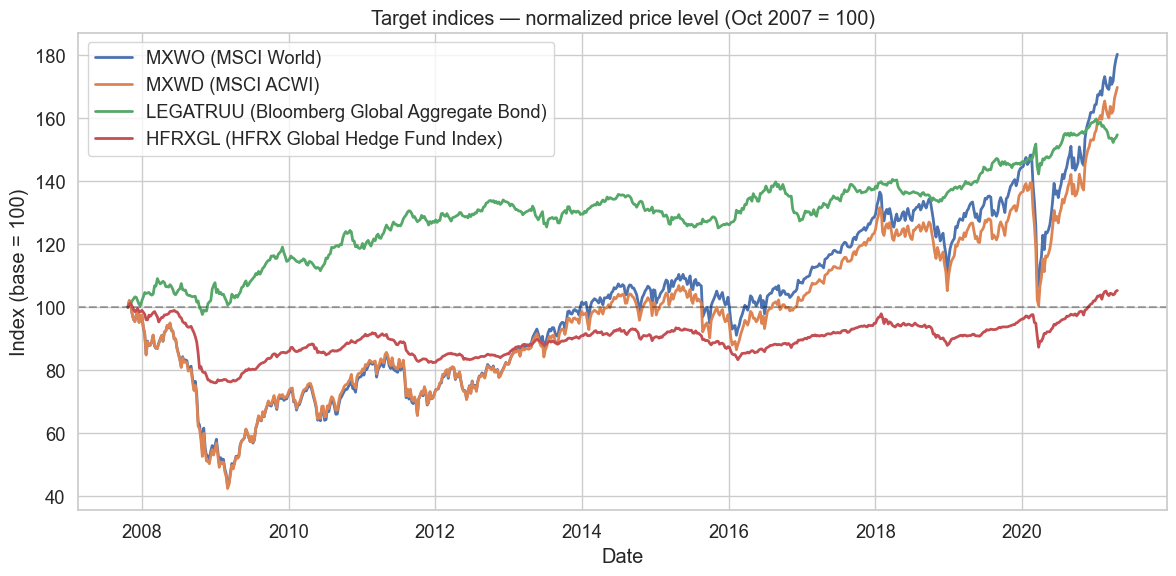

,Ann. Return,Ann. Volatility,Sharpe,Max Drawdown,Skew,Kurtosis
MXWO,5.9%,17.52%,0.34,-57.61%,-0.68,4.36
MXWD,5.51%,17.78%,0.31,-58.39%,-0.64,4.66
LEGATRUU,3.37%,5.34%,0.63,-10.41%,-0.33,4.12
HFRXGL,0.5%,4.78%,0.10,-24.91%,-2.30,13.70


In [9]:
# Normalized price levels (base 100) — visual sanity check
plt.figure(figsize=(12, 6))
for tk in TARGETS:
    s = data[tk] / data[tk].iloc[0] * 100
    plt.plot(s.index, s, lw=2, label=f"{tk} ({meta[tk][0]})")
plt.axhline(100, color='black', ls='--', alpha=0.3)
plt.title('Target indices — normalized price level (Oct 2007 = 100)')
plt.xlabel('Date'); plt.ylabel('Index (base = 100)')
plt.legend(); plt.tight_layout(); plt.show()

# Annualized statistics on weekly returns
returns = data[TARGETS].pct_change().dropna()
ANN = 52  # weekly frequency

stats_table = pd.DataFrame({
    'Ann. Return':     returns.mean() * ANN,
    'Ann. Volatility': returns.std() * np.sqrt(ANN),
    'Sharpe':          returns.mean() * ANN / (returns.std() * np.sqrt(ANN)),
    'Max Drawdown':    returns.apply(lambda x: ((1 + x).cumprod() / (1 + x).cumprod().cummax() - 1).min()),
    'Skew':            returns.skew(),
    'Kurtosis':        returns.kurtosis(),
})

# pretty-print percentages
for c in ['Ann. Return', 'Ann. Volatility', 'Max Drawdown']:
    stats_table[c] = (stats_table[c] * 100).round(2).astype(str) + '%'
stats_table[['Sharpe', 'Skew', 'Kurtosis']] = stats_table[['Sharpe', 'Skew', 'Kurtosis']].round(2)
display(stats_table)


### Distribution and dependence diagnostics — *modified by Claudio (cerro)*

**Why we now do more than just a correlation heatmap.** Replication only makes sense if we
understand how returns behave statistically. Three additions matter:

1. **Sortino and Calmar ratios.** Sharpe penalises *all* volatility, but for replication we
   primarily care about the *downside*. Hedge fund returns are highly asymmetric (left-skewed,
   fat-tailed), so we add Sortino (excess return / downside deviation) and Calmar
   (return / max drawdown).
2. **Stationarity check (ADF / KPSS).** Linear regression on returns assumes (weak)
   stationarity. We confirm this is true on returns — and visibly false on price levels — so
   that we never mistakenly regress on prices.
3. **Conditional correlations on stress regimes.** We split the sample on rolling 26-week
   volatility quantiles. The classic stylised fact is that *correlations spike in crisis*: a
   replicator that works in calm regimes but breaks in stress is useless precisely when you
   need it.

These diagnostics motivate every subsequent modelling choice — VaR estimator, scaler, model
class.


In [10]:
from statsmodels.tsa.stattools import adfuller, kpss

# Downside-aware ratios
def downside_dev(r):
    neg = r[r < 0]
    return neg.std() * np.sqrt(ANN) if len(neg) else np.nan

extra = pd.DataFrame({
    'Sortino': returns.apply(lambda r: r.mean() * ANN / downside_dev(r)),
    'Calmar':  returns.apply(lambda r: (r.mean() * ANN) /
                             abs(((1 + r).cumprod() / (1 + r).cumprod().cummax() - 1).min())),
}).round(2)
display(extra)

# Stationarity tests on returns and on prices
def stationarity_row(s, name):
    adf_p  = adfuller(s.dropna(), autolag='AIC')[1]
    kpss_p = kpss(s.dropna(), nlags='auto')[1]
    return {'series': name, 'ADF p-val': adf_p, 'KPSS p-val': kpss_p}

rows = []
for tk in TARGETS:
    rows.append(stationarity_row(data[tk],          f'{tk} (price)'))
    rows.append(stationarity_row(returns[tk],       f'{tk} (returns)'))
print("Stationarity tests — ADF: H0 = unit root (low p ⇒ stationary); "
      "KPSS: H0 = stationary (low p ⇒ NOT stationary)")
display(pd.DataFrame(rows).round(4))

# Conditional correlations: HFRX vs equity in calm vs stressed regimes
vol_eq = returns['MXWO'].rolling(26).std()
calm   = vol_eq <= vol_eq.quantile(0.5)
stress = vol_eq >= vol_eq.quantile(0.8)

cond = pd.DataFrame({
    'Calm   (vol ≤ 50th pct)':  returns.loc[calm].corr().loc['HFRXGL', TARGETS],
    'Stress (vol ≥ 80th pct)':  returns.loc[stress].corr().loc['HFRXGL', TARGETS],
}).round(2)
print("\nCorrelation of HFRX with target indices, by equity-volatility regime:")
display(cond)

,Sortino,Calmar
MXWO,0.41,0.10
MXWD,0.38,0.09
LEGATRUU,0.89,0.32
HFRXGL,0.10,0.02


Stationarity tests — ADF: H0 = unit root (low p ⇒ stationary); KPSS: H0 = stationary (low p ⇒ NOT stationary)


,series,ADF p-val,KPSS p-val
0,MXWO (price),0.9905,0.01
1,MXWO (returns),0.0000,0.10
2,MXWD (price),0.9854,0.01
3,MXWD (returns),0.0000,0.10
4,LEGATRUU (price),0.6697,0.01
5,LEGATRUU (returns),0.0000,0.10
6,HFRXGL (price),0.1701,0.01
7,HFRXGL (returns),0.0000,0.10



Correlation of HFRX with target indices, by equity-volatility regime:


,Calm (vol ≤ 50th pct),Stress (vol ≥ 80th pct)
MXWO,0.53,0.43
MXWD,0.54,0.43
LEGATRUU,-0.08,0.41
HFRXGL,1.00,1.00


Avvio Rolling Window per Idea 4 (Replica di HFRXGL)...
Completata Idea 4!


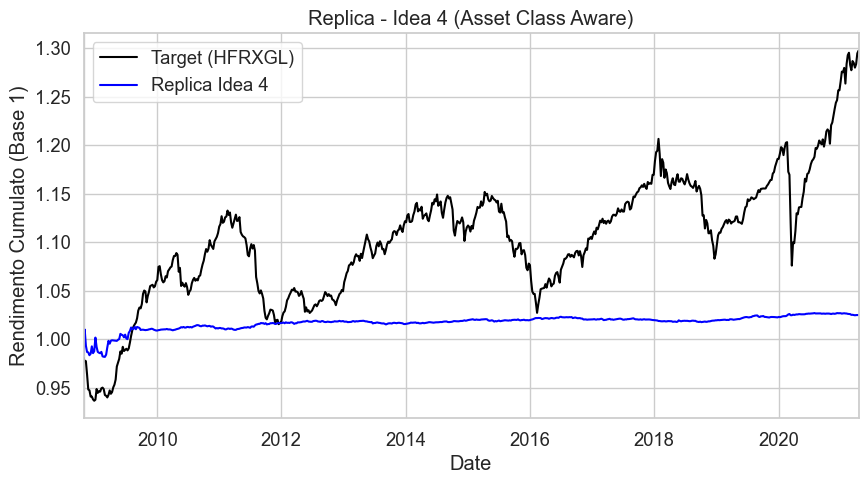

In [11]:
# ==============================================================
# ESECUZIONE IDEA 4: ASSET CLASS AWARE
# ==============================================================
from scipy.optimize import minimize
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# CORREZIONE: Ricalcoliamo i ritorni per TUTTE le colonne (Target + Futures)
returns_all = data.pct_change().dropna()

# Setup Variabili
window_size = 52
target_idx = 'HFRXGL'
y = returns_all[target_idx]
X = returns_all[FUTURES]

# Indici delle asset class per i vincoli
equity_indices = [i for i, tk in enumerate(FUTURES) if 'Equity' in meta[tk][1]]
bond_indices = [i for i, tk in enumerate(FUTURES) if 'Bond' in meta[tk][1]]

predicted_returns_idea4 = []
actual_returns_idea4 = []
weights_history_idea4 = []

print(f"Avvio Rolling Window per Idea 4 (Replica di {target_idx})...")

for i in range(window_size, len(returns_all)):
    X_train = X.iloc[i-window_size:i].values
    y_train = y.iloc[i-window_size:i].values
    X_test = X.iloc[i:i+1].values
    
    actual_returns_idea4.append(y.iloc[i])
    
    # Funzione Obiettivo
    def objective_function(w, X_mat, y_vec):
        return np.mean((y_vec - X_mat @ w)**2)
    
    # Vincoli Consapevoli
    def equity_constraint(w): return 0.8 - np.sum(w[equity_indices]) 
    def bond_constraint(w): return np.sum(w[bond_indices]) - 0.1 

    constraints = [
        {'type': 'ineq', 'fun': equity_constraint},
        {'type': 'ineq', 'fun': bond_constraint}
    ]
    
    # Ottimizzazione
    res = minimize(objective_function, np.zeros(len(FUTURES)), args=(X_train, y_train), constraints=constraints)
    w_idea4 = res.x
    weights_history_idea4.append(w_idea4)
    predicted_returns_idea4.append((X_test @ w_idea4)[0])

print("Completata Idea 4!")

# Valutazione e Plot
res_idea4_df = pd.DataFrame({
    'Target (HFRXGL)': actual_returns_idea4,
    'Replica Idea 4': predicted_returns_idea4
}, index=returns_all.index[window_size:])

(1 + res_idea4_df).cumprod().plot(figsize=(10,5), title='Replica - Idea 4 (Asset Class Aware)', color=['black', 'blue'])
plt.ylabel('Rendimento Cumulato (Base 1)')
plt.grid(True)
plt.show()

Avvio Rolling Window per Idea 5 (Replica di HFRXGL)...
Completata Idea 5!


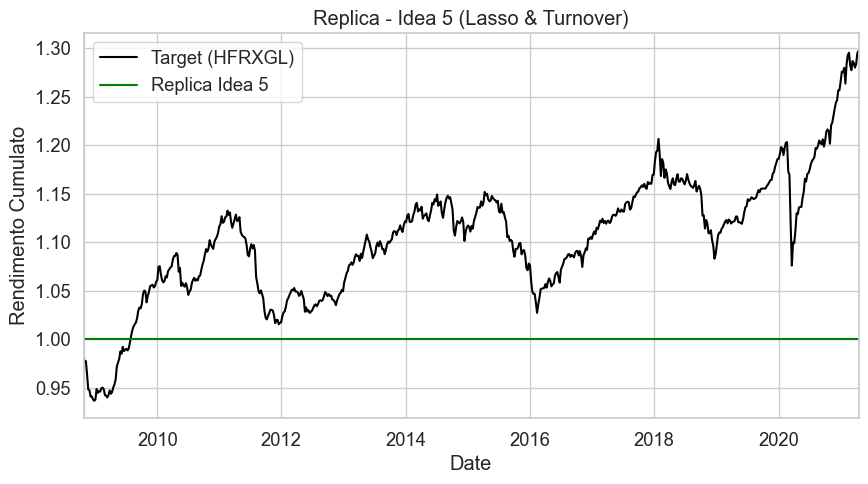

Turnover medio a ribilanciamento (Idea 5): 0.00%


In [12]:
# ==============================================================
# ESECUZIONE IDEA 5: REGOLARIZZAZIONE (LASSO) E TURNOVER
# ==============================================================
from sklearn.linear_model import Lasso
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Setup Variabili (nel caso venga eseguita indipendentemente)
window_size = 52
target_idx = 'HFRXGL'
returns_all = data.pct_change().dropna()
y = returns_all[target_idx]
X = returns_all[FUTURES]

predicted_returns_idea5 = []
actual_returns_idea5 = []
weights_history_idea5 = []

# Inizializzo i pesi del periodo precedente a 0
prev_weights_idea5 = np.zeros(len(FUTURES))

print(f"Avvio Rolling Window per Idea 5 (Replica di {target_idx})...")

for i in range(window_size, len(returns_all)):
    X_train = X.iloc[i-window_size:i].values
    y_train = y.iloc[i-window_size:i].values
    X_test = X.iloc[i:i+1].values
    
    actual_returns_idea5.append(y.iloc[i])
    
    # Modello LASSO
    lasso = Lasso(alpha=0.0005, fit_intercept=False, max_iter=5000)
    lasso.fit(X_train, y_train)
    suggested_weights = lasso.coef_
    
    # Filtro Turnover (Soglia del 3%)
    w_idea5 = np.copy(suggested_weights)
    weight_changes = np.abs(suggested_weights - prev_weights_idea5)
    for j in range(len(w_idea5)):
        if weight_changes[j] < 0.03:
            w_idea5[j] = prev_weights_idea5[j]
            
    # Aggiorna i pesi per il prossimo ciclo
    prev_weights_idea5 = np.copy(w_idea5)
    weights_history_idea5.append(w_idea5)
    predicted_returns_idea5.append((X_test @ w_idea5)[0])

print("Completata Idea 5!")

# Valutazione, Plot e Turnover Idea 5
res_idea5_df = pd.DataFrame({
    'Target (HFRXGL)': actual_returns_idea5,
    'Replica Idea 5': predicted_returns_idea5
}, index=returns_all.index[window_size:])

(1 + res_idea5_df).cumprod().plot(figsize=(10,5), title='Replica - Idea 5 (Lasso & Turnover)', color=['black', 'green'])
plt.ylabel('Rendimento Cumulato')
plt.grid(True)
plt.show()

# Calcolo del turnover medio
weights_df_idea5 = pd.DataFrame(weights_history_idea5, columns=FUTURES)
mean_turnover = weights_df_idea5.diff().abs().sum(axis=1).mean()
print(f"Turnover medio a ribilanciamento (Idea 5): {mean_turnover:.2%}")

### Correlation & probability distribution analysis

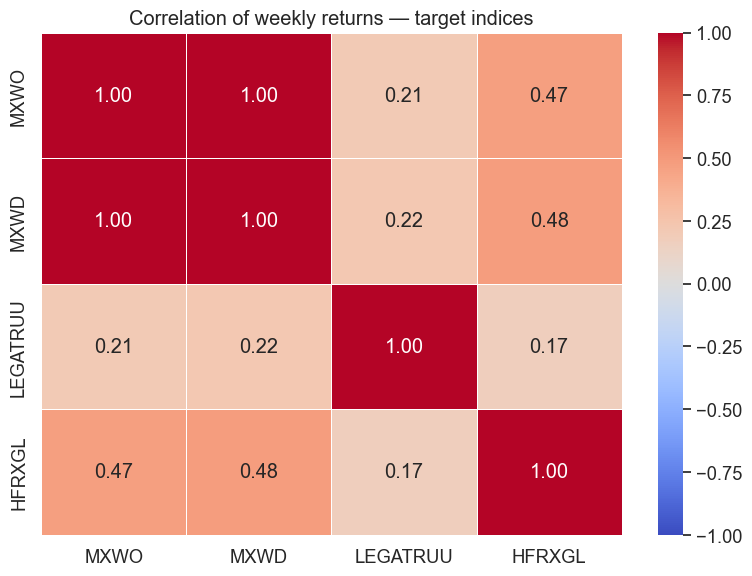

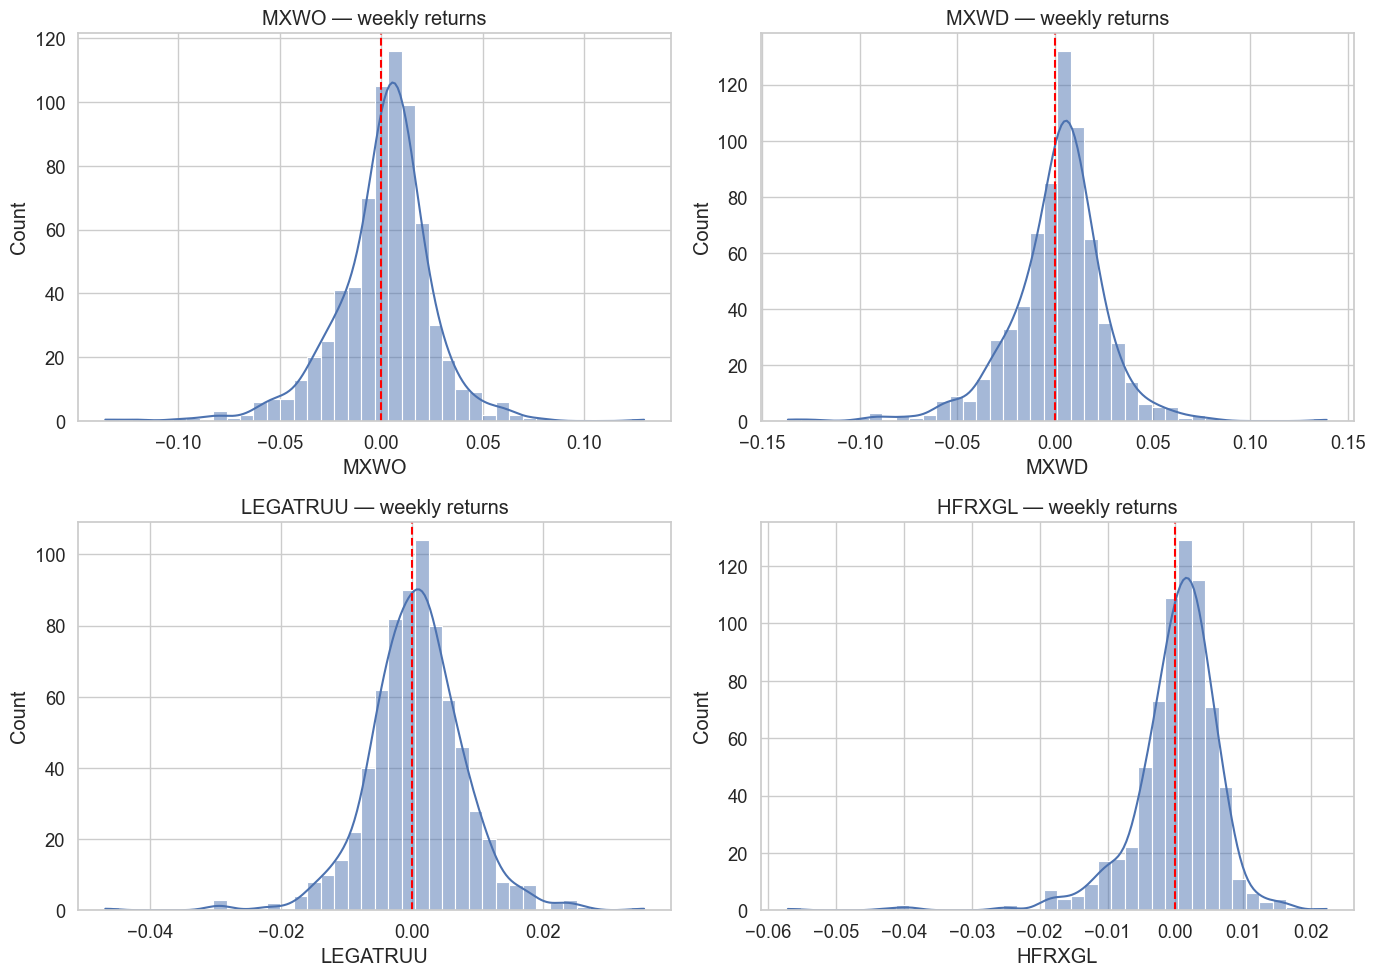

In [13]:
# Correlation heatmap on weekly returns
plt.figure(figsize=(8, 6))
sns.heatmap(returns.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f',
            linewidths=0.5)
plt.title('Correlation of weekly returns — target indices')
plt.tight_layout(); plt.show()

# Return distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, tk in zip(axes.flatten(), TARGETS):
    sns.histplot(returns[tk], kde=True, ax=ax, bins=40)
    ax.set_title(f'{tk} — weekly returns')
    ax.axvline(0, color='red', ls='--')
plt.tight_layout(); plt.show()


HFRX AR(1)             : 0.215
HFRX vol (reported)    : 4.78%
HFRX vol (unsmoothed)  : 5.95%


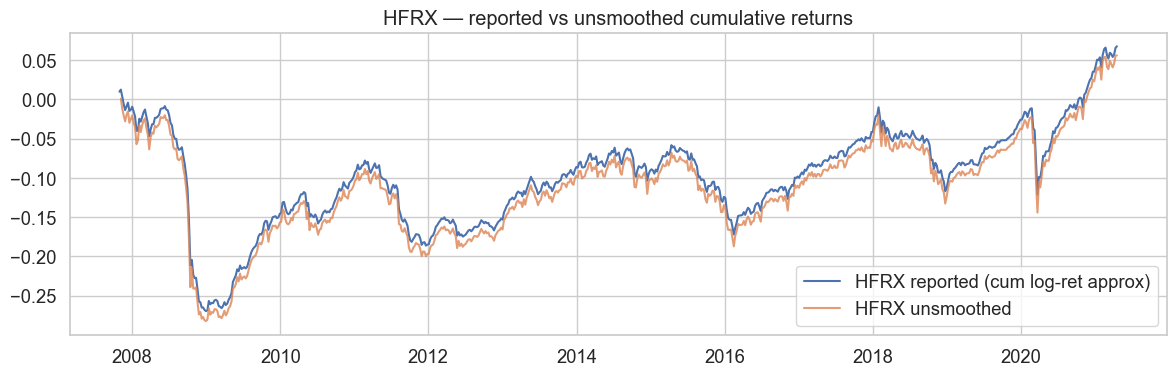

In [14]:
def unsmooth_ar1(series):
    rho = series.autocorr(lag=1)
    unsmoothed = (series - rho * series.shift(1)) / (1 - rho)
    return unsmoothed.dropna(), rho

hfrx_ret = data['HFRXGL'].pct_change().dropna()
hfrx_unsmoothed, rho = unsmooth_ar1(hfrx_ret)

print(f"HFRX AR(1)             : {rho:.3f}")
print(f"HFRX vol (reported)    : {hfrx_ret.std() * np.sqrt(ANN) * 100:.2f}%")
print(f"HFRX vol (unsmoothed)  : {hfrx_unsmoothed.std() * np.sqrt(ANN) * 100:.2f}%")

plt.figure(figsize=(12, 4))
plt.plot(hfrx_ret.cumsum(),          label='HFRX reported (cum log-ret approx)')
plt.plot(hfrx_unsmoothed.cumsum(),   label='HFRX unsmoothed', alpha=0.8)
plt.title('HFRX — reported vs unsmoothed cumulative returns')
plt.legend(); plt.tight_layout(); plt.show()


In [15]:
WEIGHTS = {'HFRXGL': 0.50, 'MXWO': 0.25, 'LEGATRUU': 0.25}

# Component weekly returns (HFRX = unsmoothed)
comp = pd.DataFrame({
    'HFRXGL':   hfrx_unsmoothed,
    'MXWO':     data['MXWO'].pct_change(),
    'LEGATRUU': data['LEGATRUU'].pct_change(),
}).dropna()

target = sum(comp[c] * w for c, w in WEIGHTS.items()).rename('Target')

# Futures returns aligned with target
futures_ret = data[FUTURES].pct_change().dropna()
common_idx  = target.index.intersection(futures_ret.index)
target      = target.loc[common_idx]
futures_ret = futures_ret.loc[common_idx]

print(f"Target observations  : {len(target)}")
print(f"Range                : {target.index.min().date()} -> {target.index.max().date()}")

# Quick stats of the target
def perf_stats(r, ann=ANN):
    cum = (1 + r).cumprod()
    return pd.Series({
        'Ann. Return':     r.mean() * ann,
        'Ann. Vol':        r.std() * np.sqrt(ann),
        'Sharpe':          r.mean() * ann / (r.std() * np.sqrt(ann)),
        'Max DD':          (cum / cum.cummax() - 1).min(),
        'Skew':            r.skew(),
        'Kurtosis':        r.kurtosis(),
    })

print("\nMonster Index statistics:")
display(perf_stats(target).round(4))


Target observations  : 703
Range                : 2007-11-06 -> 2021-04-20

Monster Index statistics:


Ann. Return    0.0248
Ann. Vol       0.0679
Sharpe         0.3650
Max DD        -0.2916
Skew          -1.2747
Kurtosis       7.8453
dtype: float64

### Target vs Futures — correlation snapshot

In [16]:
corr_with_target = (futures_ret.corrwith(target)
                                .sort_values(key=abs, ascending=False)
                                .to_frame('Corr with Target'))
display(corr_with_target.round(3))


,Corr with Target
ES1,0.823
NQ1,0.733
VG1,0.714
TP1,0.599
LLL1,0.477
CO1,0.426
DU1,-0.247
GC1,0.198
TU2,-0.154
RX1,-0.121


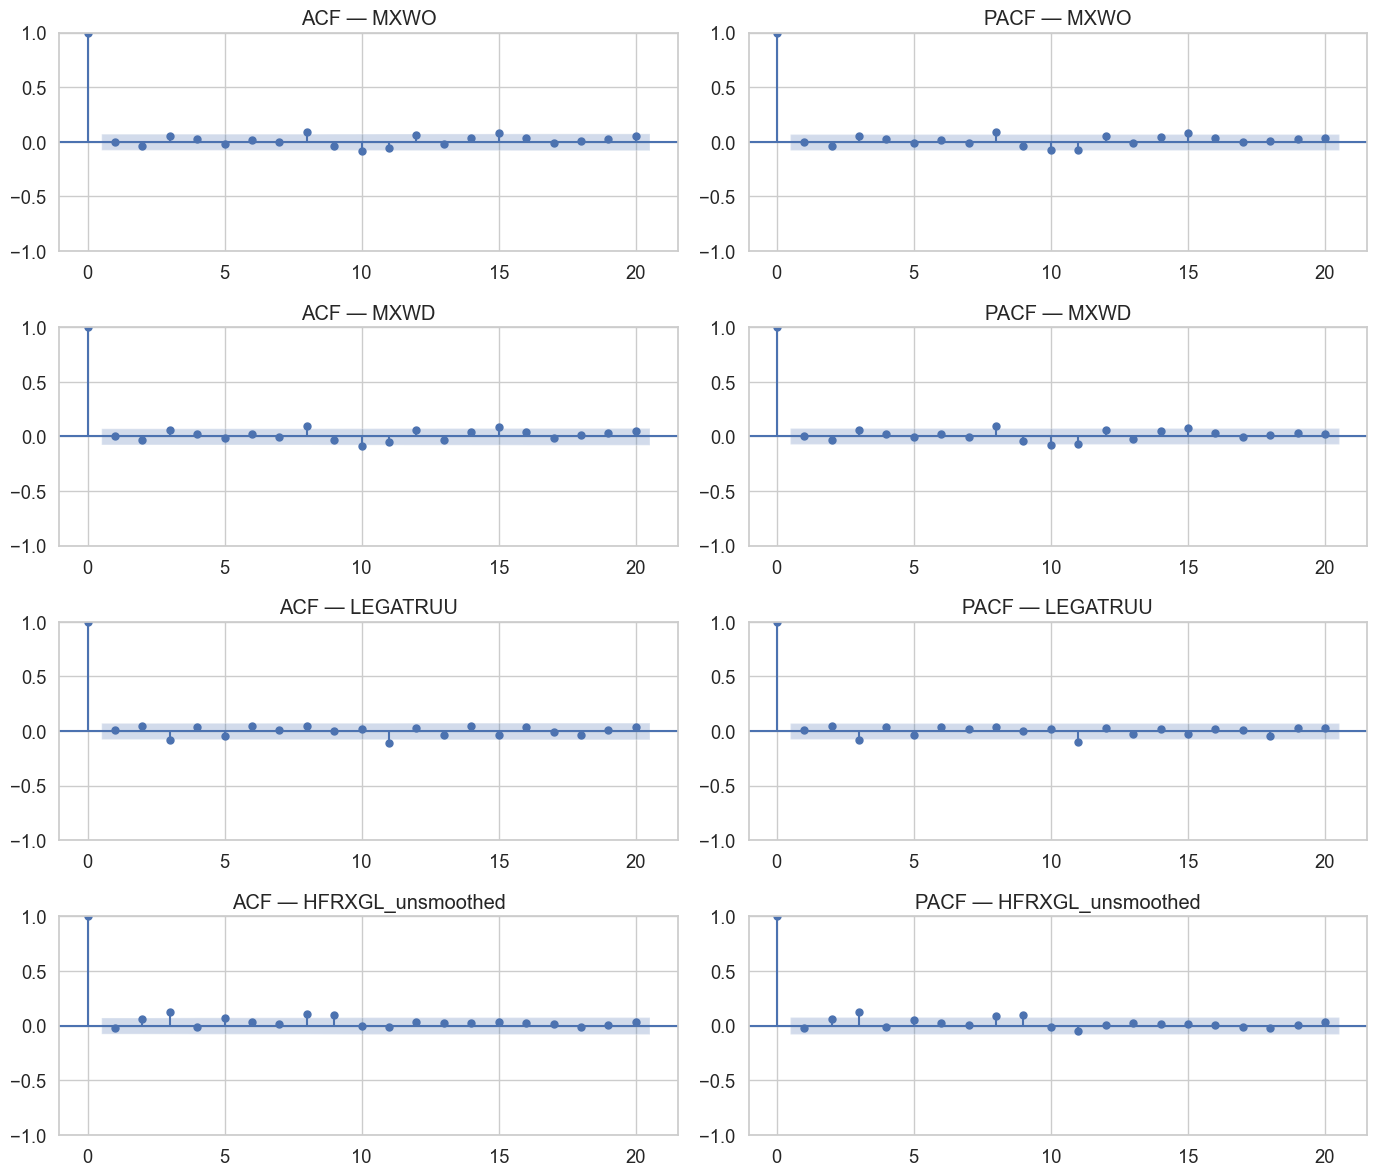

Ljung-Box test (H0: no autocorrelation up to lag k)

MXWO
    lb_stat  lb_pvalue
5    3.7464     0.5865
10  15.9826     0.1001
20  31.2007     0.0526

MXWD
    lb_stat  lb_pvalue
5    4.1064     0.5342
10  17.0352     0.0736
20  32.0539     0.0427

LEGATRUU
    lb_stat  lb_pvalue
5    8.3327     0.1388
10  11.7546     0.3018
20  26.9305     0.1372

HFRXGL_unsmoothed
    lb_stat  lb_pvalue
5   17.2759     0.0040
10  32.7442     0.0003
20  36.0300     0.0153


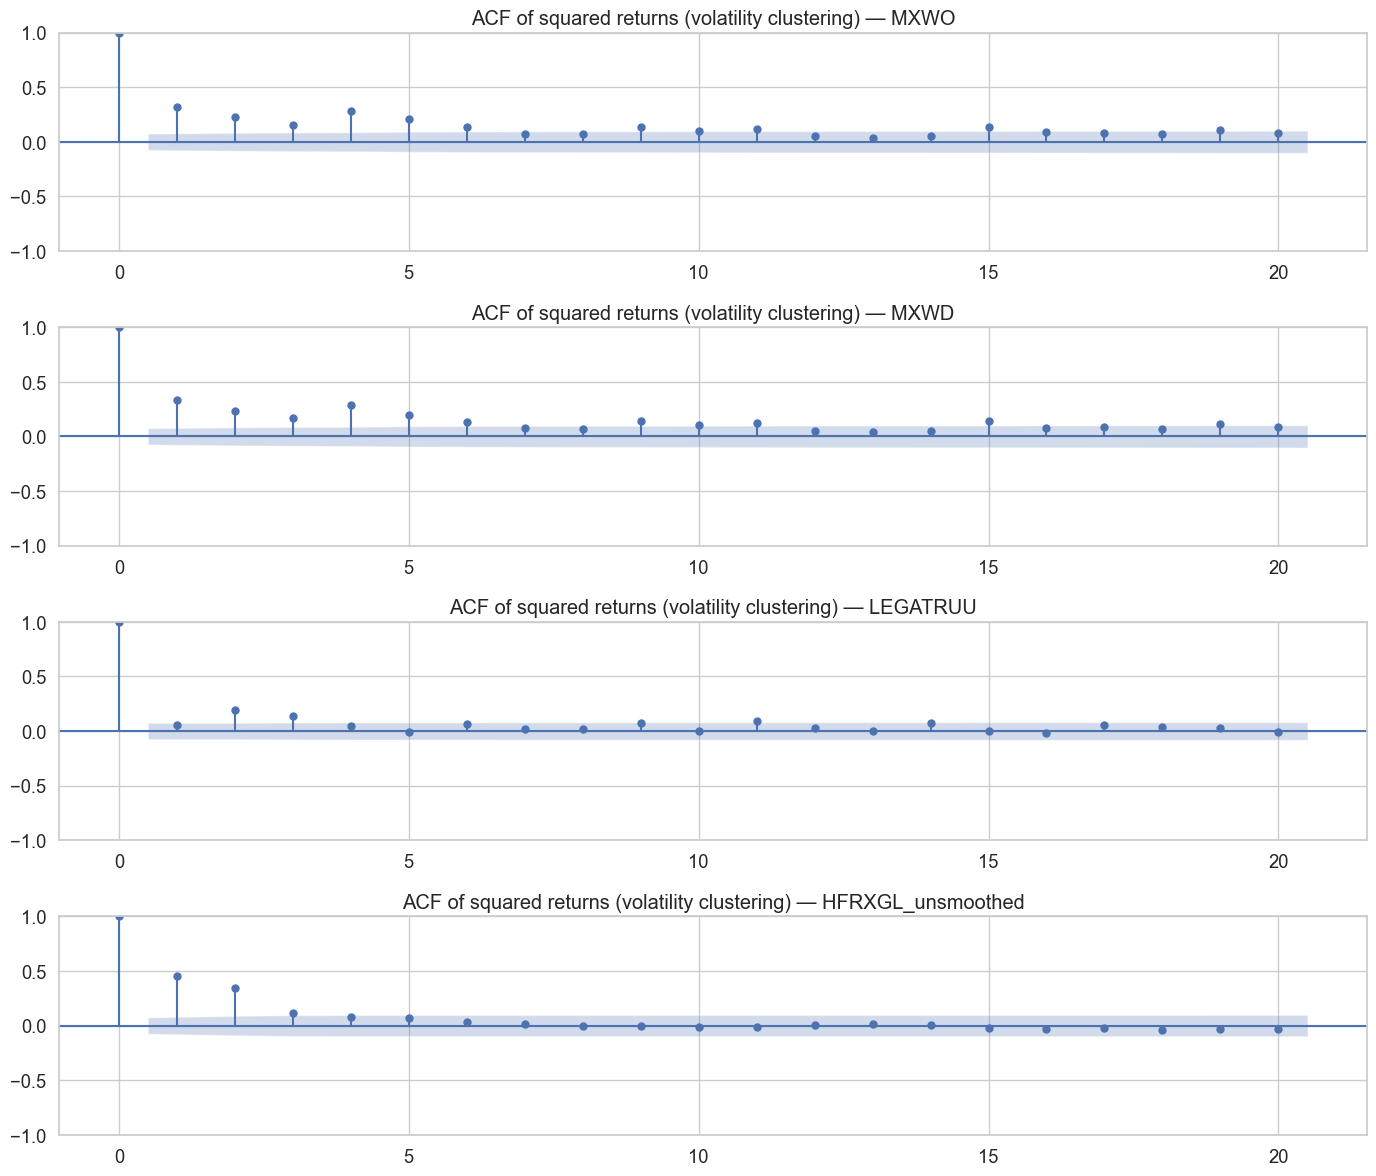

In [17]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

MAX_LAGS = 20

# ACF / PACF on the four target indices (using clean returns, with HFRX unsmoothed)
clean_returns = pd.DataFrame({
    'MXWO':     data['MXWO'].pct_change(),
    'MXWD':     data['MXWD'].pct_change(),
    'LEGATRUU': data['LEGATRUU'].pct_change(),
    'HFRXGL_unsmoothed': hfrx_unsmoothed,
}).dropna()

fig, axes = plt.subplots(len(clean_returns.columns), 2,
                         figsize=(14, 3 * len(clean_returns.columns)))
for i, col in enumerate(clean_returns.columns):
    plot_acf (clean_returns[col], lags=MAX_LAGS, ax=axes[i, 0],
              title=f'ACF — {col}')
    plot_pacf(clean_returns[col], lags=MAX_LAGS, ax=axes[i, 1],
              title=f'PACF — {col}')
plt.tight_layout(); plt.show()

# Ljung-Box on returns
print("Ljung-Box test (H0: no autocorrelation up to lag k)")
for col in clean_returns.columns:
    lb = acorr_ljungbox(clean_returns[col], lags=[5, 10, 20], return_df=True)
    print(f"\n{col}")
    print(lb.round(4).to_string())

# Volatility clustering: ACF of squared returns
fig, axes = plt.subplots(len(clean_returns.columns), 1,
                         figsize=(14, 3 * len(clean_returns.columns)))
for i, col in enumerate(clean_returns.columns):
    plot_acf(clean_returns[col]**2, lags=MAX_LAGS, ax=axes[i],
             title=f'ACF of squared returns (volatility clustering) — {col}')
plt.tight_layout(); plt.show()


In [18]:
def var_gaussian(returns, conf=0.01, horizon=4):
    sigma = np.std(returns, ddof=1)
    z = stats.norm.ppf(conf)
    return -z * sigma * np.sqrt(horizon)

def var_historical(returns, conf=0.01, horizon=4):
    if horizon != 1:
        sigma = np.std(returns, ddof=1)
        z_target = np.quantile(returns, conf) / sigma if sigma > 0 else 0
        return -z_target * sigma * np.sqrt(horizon)
    return -np.quantile(returns, conf)

def var_cornish_fisher(returns, conf=0.01, horizon=4):
    sigma = np.std(returns, ddof=1)
    if sigma == 0:
        return 0.0
    sk = stats.skew(returns)
    ek = stats.kurtosis(returns)  # excess kurtosis
    z  = stats.norm.ppf(conf)
    z_cf = (z
            + (z**2 - 1) * sk / 6
            + (z**3 - 3*z) * ek / 24
            - (2*z**3 - 5*z) * sk**2 / 36)
    return -z_cf * sigma * np.sqrt(horizon)


In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

# Risk and cost defaults
VAR_CONF      = 0.01
VAR_HORIZON   = 4         # weeks (≈ 1 month)
VAR_MAX       = 0.20      # 20% UCITS limit
VAR_LOOKBACK  = 156       # 3 years
TC_BPS        = 2e-4      # 2 bps per unit traded


def fit_linear_weights(model_factory, X_tr, y_tr, normalise=True):
    '''Fit any sklearn-style linear model and return coefficients on the original scale.'''
    if normalise:
        sx = StandardScaler().fit(X_tr)
        sy = StandardScaler().fit(y_tr.reshape(-1, 1))
        Xn, yn = sx.transform(X_tr), sy.transform(y_tr.reshape(-1, 1)).ravel()
        model  = model_factory().fit(Xn, yn)
        beta   = model.coef_ * sy.scale_[0] / sx.scale_
        alpha  = (model.intercept_ * sy.scale_[0] + sy.mean_[0]
                  - (beta * sx.mean_).sum())
        return beta, alpha
    model = model_factory().fit(X_tr, y_tr)
    return model.coef_, model.intercept_


def backtest(model_factory, X, y,
             rolling_window=156, rebalance_every=1,
             var_max=VAR_MAX, var_lookback=VAR_LOOKBACK,
             var_fn=var_cornish_fisher, tc_bps=TC_BPS,
             normalise=True, weight_post_fn=None):
    '''
    Generic walk-forward replication backtest.

    `model_factory()` returns a fresh sklearn-style estimator at every refit.
    `weight_post_fn(beta)` is an optional projection (e.g. non-negativity, gross-exposure cap)
    applied AFTER the regression but BEFORE risk scaling.
    '''
    Xv, yv  = X.values, y.values
    dates   = X.index.to_numpy()
    n       = len(X)
    n_assets = X.shape[1]

    weights, gross_rets, net_rets, dates_oos = [], [], [], []
    gross_exposures, var_history, scaling_history = [], [], []
    last_w = np.zeros(n_assets)

    # We initialize _alpha to 0 in case rebalance_every > 1, though it will be set on the first iteration
    _alpha = 0.0
    for i in range(rolling_window, n):
        # Refit only on rebalancing weeks; otherwise hold weights
        if (i - rolling_window) % rebalance_every == 0:
            X_tr = Xv[i - rolling_window:i]
            y_tr = yv[i - rolling_window:i]
            beta, _alpha = fit_linear_weights(model_factory, X_tr, y_tr, normalise=normalise)
            if weight_post_fn is not None:
                beta = weight_post_fn(beta)

            # Risk scaling using historical replica returns over var_lookback weeks
            hist_X   = Xv[i - var_lookback:i]
            hist_ret = hist_X @ beta + _alpha
            v        = var_fn(hist_ret, conf=VAR_CONF, horizon=VAR_HORIZON)
            scale    = min(1.0, var_max / v) if v > 0 else 1.0
            beta     = beta * scale
        else:
            v, scale = np.nan, 1.0

        # Out-of-sample step
        next_ret  = Xv[i] @ beta + _alpha
        turnover  = np.sum(np.abs(beta - last_w))
        net_ret   = next_ret - tc_bps * turnover

        weights.append(beta);    gross_rets.append(next_ret);   net_rets.append(net_ret)
        dates_oos.append(dates[i]);  gross_exposures.append(np.sum(np.abs(beta)))
        var_history.append(v);   scaling_history.append(scale)
        last_w = beta

    idx = pd.DatetimeIndex(dates_oos)
    return {
        'weights':         pd.DataFrame(weights, index=idx, columns=X.columns),
        'gross_returns':   pd.Series(gross_rets, index=idx, name='Gross'),
        'net_returns':     pd.Series(net_rets,   index=idx, name='Net'),
        'target':          y.loc[idx],
        'gross_exposure':  pd.Series(gross_exposures, index=idx),
        'var':             pd.Series(var_history,    index=idx),
        'scaling':         pd.Series(scaling_history, index=idx),
    }


def report(res, ann=ANN):
    y, g, n = res['target'], res['gross_returns'], res['net_returns']
    te_gross = (g - y).std() * np.sqrt(ann)
    te_net   = (n - y).std() * np.sqrt(ann)
    out = {
        'Target Ann.Ret':   y.mean() * ann,
        'Replica Ann.Ret (gross)': g.mean() * ann,
        'Replica Ann.Ret (net)':   n.mean() * ann,
        'Target Ann.Vol':   y.std() * np.sqrt(ann),
        'Replica Ann.Vol':  n.std() * np.sqrt(ann),
        'TE (gross)':       te_gross,
        'TE (net)':         te_net,
        'Information Ratio (gross)': (g.mean() - y.mean()) * ann / te_gross if te_gross else np.nan,
        'Information Ratio (net)':   (n.mean() - y.mean()) * ann / te_net   if te_net   else np.nan,
        'Correlation':      g.corr(y),
        'Avg gross exposure': res['gross_exposure'].mean(),
        'Avg VaR':          res['var'].mean(),
        'Avg turnover/week': res['weights'].diff().abs().sum(axis=1).mean(),
    }
    return pd.Series(out)


In [20]:
baselines = {
    'OLS':         lambda: LinearRegression(),
    'Ridge':       lambda: Ridge(alpha=1.0),
    'Lasso':       lambda: Lasso(alpha=1e-3, max_iter=10000),
    'ElasticNet':  lambda: ElasticNet(alpha=1e-3, l1_ratio=0.5, max_iter=10000),
}

baseline_results = {}
for name, factory in baselines.items():
    baseline_results[name] = backtest(factory, futures_ret, target,
                                      rolling_window=156, rebalance_every=1)

baseline_table = pd.DataFrame({k: report(v) for k, v in baseline_results.items()}).T
display(baseline_table.round(4))


,Target Ann.Ret,Replica Ann.Ret (gross),Replica Ann.Ret (net),Target Ann.Vol,Replica Ann.Vol,TE (gross),TE (net),Information Ratio (gross),Information Ratio (net),Correlation,Avg gross exposure,Avg VaR,Avg turnover/week
OLS,0.0381,0.0387,0.0376,0.0603,0.0530,0.0326,0.0326,0.0192,-0.0144,0.8421,1.9142,0.0519,0.1030
Ridge,0.0381,0.0387,0.0376,0.0603,0.0526,0.0327,0.0327,0.0181,-0.0143,0.8412,1.8776,0.0515,0.0995
Lasso,0.0381,0.0388,0.0377,0.0603,0.0528,0.0326,0.0326,0.0215,-0.0116,0.8419,1.8574,0.0517,0.1015
ElasticNet,0.0381,0.0388,0.0377,0.0603,0.0529,0.0326,0.0326,0.0201,-0.0131,0.8419,1.8828,0.0518,0.1020


In [21]:
from itertools import product
from sklearn.model_selection import TimeSeriesSplit

ALPHAS    = [1e-5, 3e-5, 1e-4, 3e-4, 1e-3, 3e-3, 1e-2]
L1_RATIOS = [0.1, 0.3, 0.5, 0.7, 0.9, 1.0]
WINDOWS   = [104, 156, 208]

# Split: first 60% for hyperparameter search, last 40% for held-out evaluation
split_at = int(len(target) * 0.6)
y_search, X_search = target.iloc[:split_at], futures_ret.iloc[:split_at]
y_eval,   X_eval   = target.iloc[split_at:], futures_ret.iloc[split_at:]

def cv_score(model_factory, X, y, n_splits=4, window=156):
    '''Mean tracking error on time series CV (lower is better).'''
    tscv = TimeSeriesSplit(n_splits=n_splits)
    tes  = []
    for tr_idx, te_idx in tscv.split(X):
        if len(tr_idx) < window:
            continue
        Xt, yt = X.iloc[tr_idx[-window:]], y.iloc[tr_idx[-window:]]
        Xv, yv = X.iloc[te_idx], y.iloc[te_idx]
        beta, alpha = fit_linear_weights(model_factory, Xt.values, yt.values, normalise=True)
        pred = Xv.values @ beta + alpha
        tes.append((pred - yv.values).std())
    return float(np.mean(tes)) if tes else np.inf

# Grid search
search_rows = []
for w, a, l1 in product(WINDOWS, ALPHAS, L1_RATIOS):
    factory = lambda a=a, l1=l1: ElasticNet(alpha=a, l1_ratio=l1, max_iter=10000)
    score   = cv_score(factory, X_search, y_search, window=w)
    search_rows.append({'window': w, 'alpha': a, 'l1_ratio': l1, 'cv_te': score})

search_df = pd.DataFrame(search_rows).sort_values('cv_te')
print("Top 5 hyperparameter configurations by CV TE (lower is better):")
display(search_df.head().round(6))

best = search_df.iloc[0]
best_window   = int(best['window'])
best_alpha    = float(best['alpha'])
best_l1_ratio = float(best['l1_ratio'])
print(f"\nSelected: window={best_window}, alpha={best_alpha}, l1_ratio={best_l1_ratio}")

# Re-run on the FULL sample with the best configuration (and a monthly variant for comparison)
best_factory = lambda: ElasticNet(alpha=best_alpha, l1_ratio=best_l1_ratio, max_iter=10000)

elnet_weekly  = backtest(best_factory, futures_ret, target,
                         rolling_window=best_window, rebalance_every=1)
elnet_monthly = backtest(best_factory, futures_ret, target,
                         rolling_window=best_window, rebalance_every=4)

comparison = pd.DataFrame({
    'OLS':                  report(baseline_results['OLS']),
    'Ridge':                report(baseline_results['Ridge']),
    'Lasso':                report(baseline_results['Lasso']),
    'ElasticNet (default)': report(baseline_results['ElasticNet']),
    'ElasticNet (tuned, weekly rebal)':  report(elnet_weekly),
    'ElasticNet (tuned, monthly rebal)': report(elnet_monthly),
}).T
display(comparison.round(4))


Top 5 hyperparameter configurations by CV TE (lower is better):


,window,alpha,l1_ratio,cv_te
125,208,0.01,1.0,0.003602
124,208,0.01,0.9,0.003606
123,208,0.01,0.7,0.003615
122,208,0.01,0.5,0.003628
121,208,0.01,0.3,0.003644



Selected: window=208, alpha=0.01, l1_ratio=1.0


,Target Ann.Ret,Replica Ann.Ret (gross),Replica Ann.Ret (net),Target Ann.Vol,Replica Ann.Vol,TE (gross),TE (net),Information Ratio (gross),Information Ratio (net),Correlation,Avg gross exposure,Avg VaR,Avg turnover/week
OLS,0.0381,0.0387,0.0376,0.0603,0.0530,0.0326,0.0326,0.0192,-0.0144,0.8421,1.9142,0.0519,0.1030
Ridge,0.0381,0.0387,0.0376,0.0603,0.0526,0.0327,0.0327,0.0181,-0.0143,0.8412,1.8776,0.0515,0.0995
Lasso,0.0381,0.0388,0.0377,0.0603,0.0528,0.0326,0.0326,0.0215,-0.0116,0.8419,1.8574,0.0517,0.1015
ElasticNet (default),0.0381,0.0388,0.0377,0.0603,0.0529,0.0326,0.0326,0.0201,-0.0131,0.8419,1.8828,0.0518,0.1020
"ElasticNet (tuned, weekly rebal)",0.0440,0.0415,0.0408,0.0585,0.0504,0.0315,0.0315,-0.0774,-0.0995,0.8431,1.2327,0.0483,0.0650
"ElasticNet (tuned, monthly rebal)",0.0440,0.0403,0.0399,0.0585,0.0506,0.0322,0.0322,-0.1145,-0.1279,0.8353,1.2357,0.0483,0.0393


### Best replica — diagnostic plots

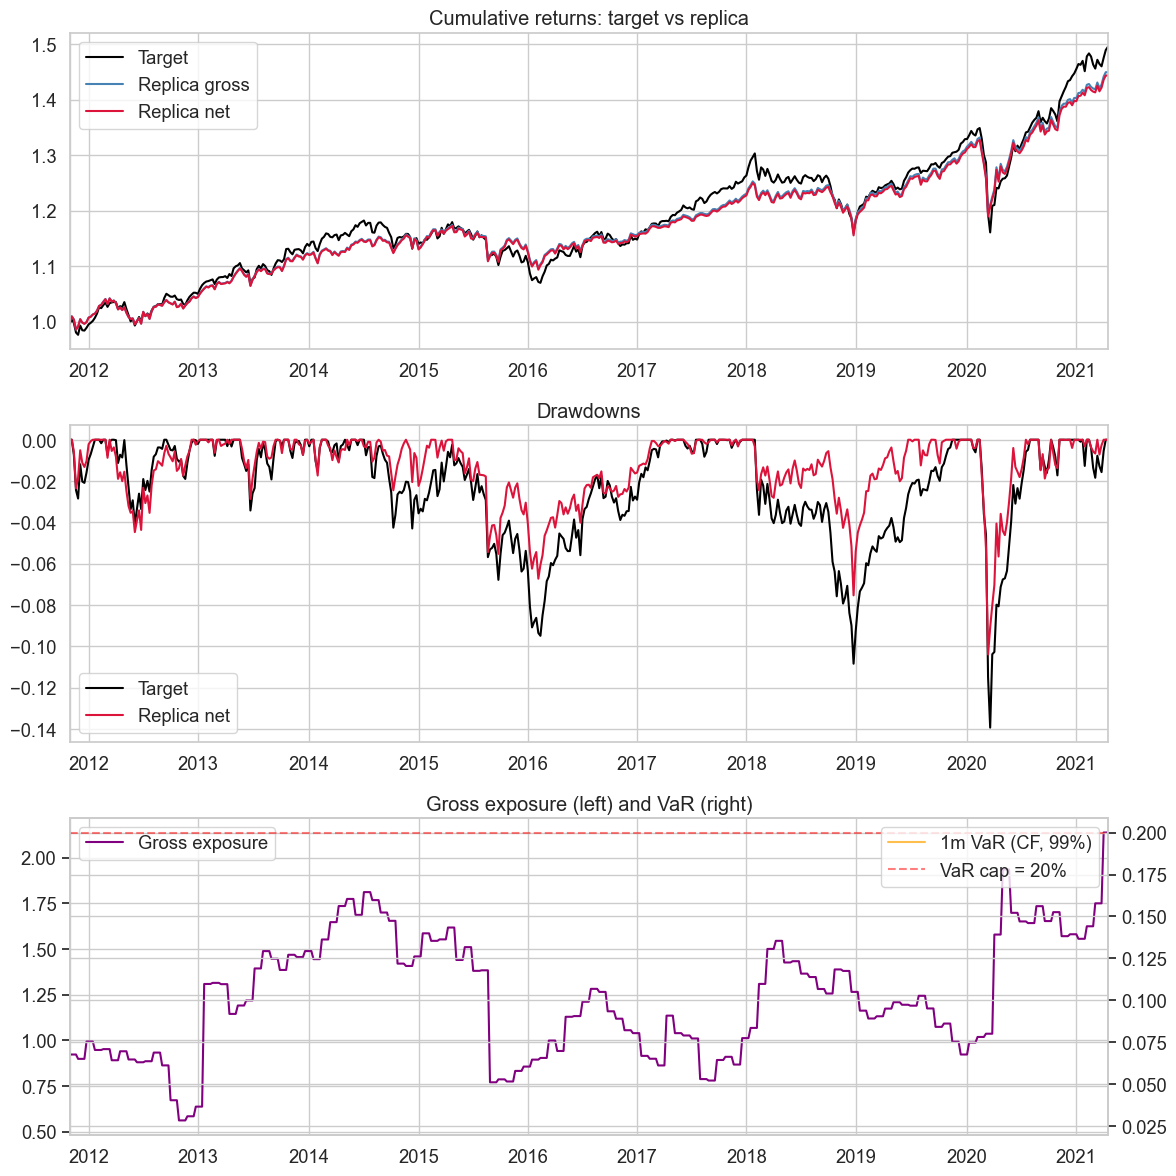

Top 10 average absolute weights:


,Average w,Final w
DU1,-0.406,1.099
ES1,0.213,0.395
TY1,0.115,0.170
RX1,0.055,0.061
VG1,0.053,0.014
GC1,0.044,0.017
TP1,0.043,0.047
TU2,0.032,-0.270
CO1,0.017,-0.002
NQ1,0.014,-0.062


In [22]:
best = elnet_monthly  # net IR favours less frequent rebalancing
y, g, n = best['target'], best['gross_returns'], best['net_returns']

fig, axes = plt.subplots(3, 1, figsize=(12, 12))

# 1) cumulative returns
(1 + y).cumprod().plot(ax=axes[0], label='Target',         color='black')
(1 + g).cumprod().plot(ax=axes[0], label='Replica gross',  color='steelblue')
(1 + n).cumprod().plot(ax=axes[0], label='Replica net',    color='crimson')
axes[0].set_title('Cumulative returns: target vs replica'); axes[0].legend()

# 2) drawdowns
def dd(s):
    c = (1 + s).cumprod()
    return c / c.cummax() - 1
dd(y).plot(ax=axes[1], label='Target',      color='black')
dd(n).plot(ax=axes[1], label='Replica net', color='crimson')
axes[1].set_title('Drawdowns'); axes[1].legend()

# 3) gross exposure & VaR
best['gross_exposure'].plot(ax=axes[2], label='Gross exposure', color='purple')
ax2 = axes[2].twinx()
best['var'].plot(ax=ax2, label='1m VaR (CF, 99%)', color='orange', alpha=0.7)
ax2.axhline(VAR_MAX, color='red', ls='--', alpha=0.5, label=f'VaR cap = {VAR_MAX:.0%}')
axes[2].set_title('Gross exposure (left) and VaR (right)')
axes[2].legend(loc='upper left'); ax2.legend(loc='upper right')

plt.tight_layout(); plt.show()

# Average and final weights
avg_w   = best['weights'].mean().sort_values(key=abs, ascending=False)
final_w = best['weights'].iloc[-1].reindex(avg_w.index)
weights_summary = pd.DataFrame({'Average w': avg_w, 'Final w': final_w}).round(3)
print("Top 10 average absolute weights:")
display(weights_summary.head(10))


,Target Ann.Ret,Replica Ann.Ret (gross),Replica Ann.Ret (net),Target Ann.Vol,Replica Ann.Vol,TE (gross),TE (net),Information Ratio (gross),Information Ratio (net),Correlation,Avg gross exposure,Avg VaR,Avg turnover/week
ElasticNet (best),0.044,0.0403,0.0399,0.0585,0.0506,0.0322,0.0322,-0.1145,-0.1279,0.8353,1.2357,0.0483,0.0393
NN-Lasso (long-only),0.044,0.0405,0.0403,0.0585,0.0517,0.0318,0.0318,-0.1094,-0.1165,0.8406,0.6869,0.0483,0.0200


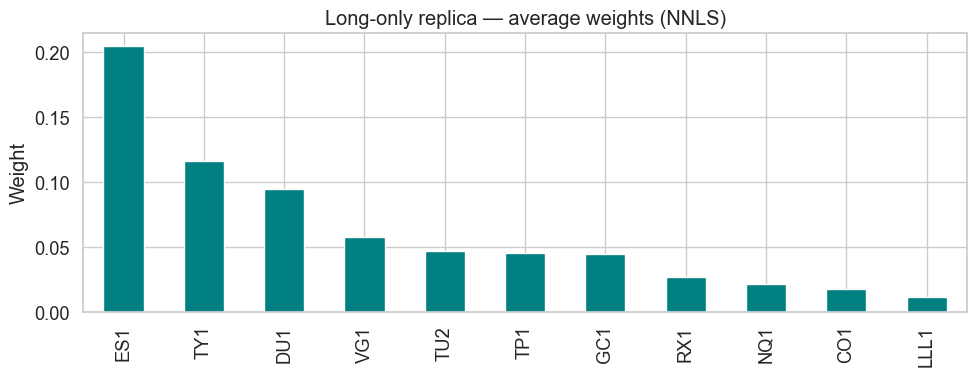

In [23]:
from scipy.optimize import nnls

class NNLSWrapper:
    '''sklearn-like wrapper around scipy.optimize.nnls with optional sparsity threshold.'''
    def __init__(self, sparsity_thresh=0.0):
        self.sparsity_thresh = sparsity_thresh
        self.coef_ = None
        self.intercept_ = 0.0

    def fit(self, X, y):
        # Centre y to mimic an intercept; coefficients are still non-negative
        y_c = y - y.mean()
        coef, _ = nnls(X, y_c)
        if self.sparsity_thresh > 0:
            coef = np.where(np.abs(coef) > self.sparsity_thresh, coef, 0.0)
        self.coef_      = coef
        self.intercept_ = float(y.mean())
        return self

nnls_factory = lambda: NNLSWrapper(sparsity_thresh=0.005)

nnls_result = backtest(nnls_factory, futures_ret, target,
                       rolling_window=best_window, rebalance_every=4)

display(pd.DataFrame({
    'ElasticNet (best)': report(elnet_monthly),
    'NN-Lasso (long-only)': report(nnls_result),
}).T.round(4))

# Plot the average composition of the long-only replica
avg_w = nnls_result['weights'].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 4))
avg_w.plot(kind='bar', color='teal')
plt.title('Long-only replica — average weights (NNLS)')
plt.ylabel('Weight'); plt.tight_layout(); plt.show()


In [24]:
def kalman_replication(X, y, init_window=156, q=1e-5, r=None,
                       var_max=VAR_MAX, var_lookback=VAR_LOOKBACK,
                       var_fn=var_cornish_fisher, tc_bps=TC_BPS):
    '''Random-walk Kalman filter on regression coefficients.'''
    Xv, yv = X.values, y.values
    n, k   = Xv.shape

    # Initialise with Ridge on the first init_window observations
    init = Ridge(alpha=1.0).fit(Xv[:init_window], yv[:init_window])
    beta = init.coef_.copy()
    P    = np.eye(k) * 0.01
    Q    = np.eye(k) * q
    if r is None:
        r = float(np.var(yv[:init_window] - init.predict(Xv[:init_window])))

    weights, gross, net, exposures, var_h, scale_h, dates_oos = [], [], [], [], [], [], []
    last_w = np.zeros(k)

    for t in range(init_window, n):
        # Risk scaling (using previous step's beta)
        hist_X   = Xv[max(0, t - var_lookback):t]
        hist_ret = hist_X @ beta
        v        = var_fn(hist_ret, conf=VAR_CONF, horizon=VAR_HORIZON)
        scale    = min(1.0, var_max / v) if v > 0 else 1.0
        beta_eff = beta * scale

        # Out-of-sample step for week t
        next_ret = Xv[t] @ beta_eff
        turn     = np.sum(np.abs(beta_eff - last_w))
        weights.append(beta_eff.copy())
        gross.append(next_ret)
        net.append(next_ret - tc_bps * turn)
        exposures.append(np.sum(np.abs(beta_eff)))
        var_h.append(v); scale_h.append(scale)
        dates_oos.append(X.index[t])
        last_w = beta_eff

        # --- Predict --- 
        P = P + Q
        # --- Update with y_t = x^T beta + noise ---
        x = Xv[t]
        S = float(x @ P @ x + r)
        K = (P @ x) / S
        innov = yv[t] - x @ beta
        beta  = beta + K * innov
        P     = P - np.outer(K, x) @ P

    idx = pd.DatetimeIndex(dates_oos)
    return {
        'weights':        pd.DataFrame(weights, index=idx, columns=X.columns),
        'gross_returns':  pd.Series(gross, index=idx, name='Gross'),
        'net_returns':    pd.Series(net,   index=idx, name='Net'),
        'target':         y.loc[idx],
        'gross_exposure': pd.Series(exposures, index=idx),
        'var':            pd.Series(var_h, index=idx),
        'scaling':        pd.Series(scale_h, index=idx),
    }

# Light grid for q (process noise)
kalman_search = []
for q in [1e-7, 1e-6, 1e-5, 1e-4, 1e-3]:
    res_q = kalman_replication(futures_ret, target, q=q)
    kalman_search.append({'q': q, **report(res_q).to_dict()})
kalman_search_df = pd.DataFrame(kalman_search).sort_values('TE (net)')
display(kalman_search_df.round(4))

best_q = kalman_search_df.iloc[0]['q']
kalman_best = kalman_replication(futures_ret, target, q=best_q)

display(pd.DataFrame({
    'ElasticNet (tuned)':   report(elnet_monthly),
    'NN-Lasso (long-only)': report(nnls_result),
    f'Kalman (q={best_q:.0e})': report(kalman_best),
}).T.round(4))


,q,Target Ann.Ret,Replica Ann.Ret (gross),Replica Ann.Ret (net),Target Ann.Vol,Replica Ann.Vol,TE (gross),TE (net),Information Ratio (gross),Information Ratio (net),Correlation,Avg gross exposure,Avg VaR,Avg turnover/week
0,0.0000,0.0381,0.0378,0.0377,0.0603,0.0500,0.0324,0.0324,-0.0092,-0.0119,0.8438,0.5266,0.0487,0.0082
1,0.0000,0.0381,0.0380,0.0379,0.0603,0.0499,0.0326,0.0326,-0.0039,-0.0068,0.8417,0.5276,0.0486,0.0086
2,0.0000,0.0381,0.0401,0.0400,0.0603,0.0508,0.0332,0.0332,0.0605,0.0568,0.8344,0.5422,0.0493,0.0116
3,0.0001,0.0381,0.0424,0.0421,0.0603,0.0528,0.0342,0.0342,0.1246,0.1170,0.8246,0.6174,0.0514,0.0246
4,0.0010,0.0381,0.0375,0.0368,0.0603,0.0551,0.0356,0.0356,-0.0181,-0.0374,0.8136,0.8257,0.0533,0.0655


,Target Ann.Ret,Replica Ann.Ret (gross),Replica Ann.Ret (net),Target Ann.Vol,Replica Ann.Vol,TE (gross),TE (net),Information Ratio (gross),Information Ratio (net),Correlation,Avg gross exposure,Avg VaR,Avg turnover/week
ElasticNet (tuned),0.0440,0.0403,0.0399,0.0585,0.0506,0.0322,0.0322,-0.1145,-0.1279,0.8353,1.2357,0.0483,0.0393
NN-Lasso (long-only),0.0440,0.0405,0.0403,0.0585,0.0517,0.0318,0.0318,-0.1094,-0.1165,0.8406,0.6869,0.0483,0.0200
Kalman (q=1e-07),0.0381,0.0378,0.0377,0.0603,0.0500,0.0324,0.0324,-0.0092,-0.0119,0.8438,0.5266,0.0487,0.0082


### Side-by-side comparison of all replicators — *added by Claudio (cerro)*

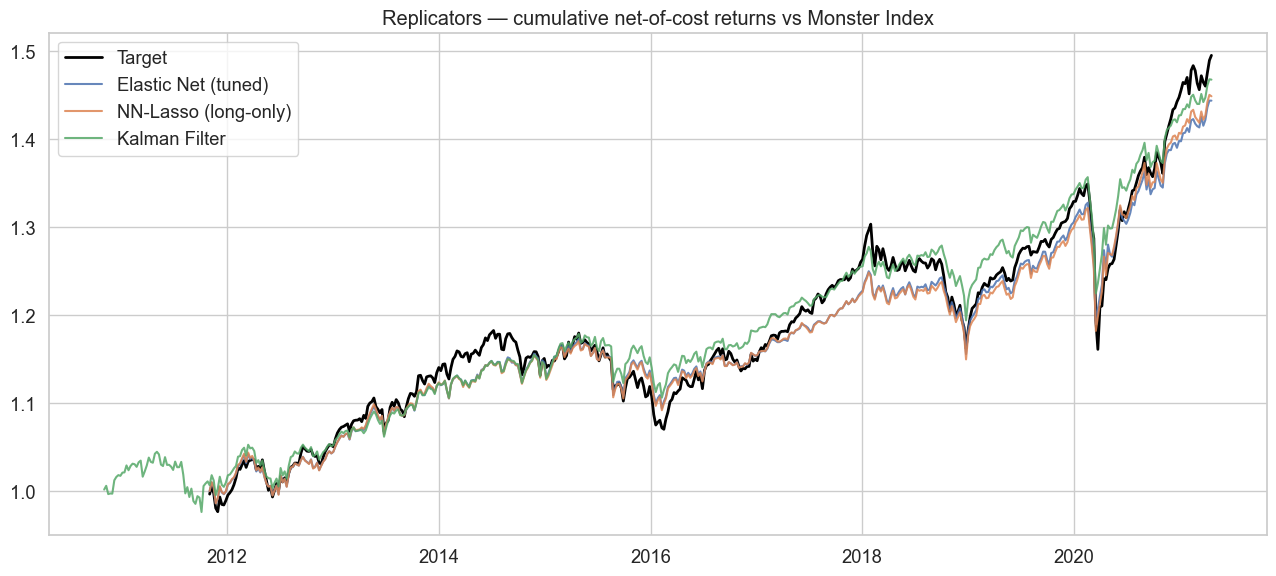

In [25]:
def cum(s):
    return (1 + s).cumprod()

plt.figure(figsize=(13, 6))
plt.plot(cum(elnet_monthly['target']),                  label='Target', color='black', lw=2)
plt.plot(cum(elnet_monthly['net_returns']),             label='Elastic Net (tuned)', alpha=0.85)
plt.plot(cum(nnls_result['net_returns']),               label='NN-Lasso (long-only)', alpha=0.85)
plt.plot(cum(kalman_best['net_returns']),               label='Kalman Filter',        alpha=0.85)
plt.title('Replicators — cumulative net-of-cost returns vs Monster Index')
plt.legend(); plt.tight_layout(); plt.show()


### Bootstrap confidence intervals for TE and IR — *added by Claudio (cerro)*

A point estimate of tracking error or information ratio is almost meaningless without an
uncertainty band. Two replicators with TE 4.0% and 4.5% can be statistically
indistinguishable, and you should not switch from one to the other on a 0.5% difference.

We use a **stationary (block) bootstrap** with a mean block length of 8 weeks (about 2
months) to preserve the autocorrelation structure of returns. The output is a 95%
confidence interval for both TE and net IR.


In [26]:
def stationary_bootstrap(s_target, s_replica, n_boot=500, mean_block=8, ann=52, seed=7):
    rng = np.random.default_rng(seed)
    n = len(s_target)
    idx_all = np.arange(n)
    p = 1.0 / mean_block
    te_boot, ir_boot = [], []

    for _ in range(n_boot):
        sample_idx = []
        i = rng.integers(0, n)
        while len(sample_idx) < n:
            sample_idx.append(idx_all[i % n])
            if rng.random() < p:
                i = rng.integers(0, n)
            else:
                i += 1
        sample_idx = np.array(sample_idx[:n])
        diff = s_replica.values[sample_idx] - s_target.values[sample_idx]
        te = diff.std() * np.sqrt(ann)
        ir = diff.mean() * ann / te if te > 0 else np.nan
        te_boot.append(te); ir_boot.append(ir)

    return {
        'TE 95% CI': (np.quantile(te_boot, 0.025), np.quantile(te_boot, 0.975)),
        'IR 95% CI': (np.quantile(ir_boot, 0.025), np.quantile(ir_boot, 0.975)),
    }

ci_table = []
for name, res in [('Elastic Net (tuned)', elnet_monthly),
                  ('NN-Lasso',            nnls_result),
                  (f'Kalman (q={best_q:.0e})', kalman_best)]:
    ci = stationary_bootstrap(res['target'], res['net_returns'])
    ci_table.append({
        'Model': name,
        'TE 2.5%': ci['TE 95% CI'][0],
        'TE 97.5%': ci['TE 95% CI'][1],
        'IR 2.5%': ci['IR 95% CI'][0],
        'IR 97.5%': ci['IR 95% CI'][1],
    })
display(pd.DataFrame(ci_table).round(4))


,Model,TE 2.5%,TE 97.5%,IR 2.5%,IR 97.5%
0,Elastic Net (tuned),0.0243,0.0434,-0.6493,0.3072
1,NN-Lasso,0.0244,0.0423,-0.6367,0.3085
2,Kalman (q=1e-07),0.0261,0.0413,-0.5881,0.4567


# Original ideas to push the work further

The previous sections fixed the existing pipeline and added strong baselines (NNLS, Kalman).
What follows are **proposals that go beyond the standard textbook treatment** and that, in
my opinion, would create real-world value. I describe each idea, the statistical argument
behind it, and the financial motivation. They are not implemented here because each deserves
its own notebook — and prioritising them is itself a discussion.


### Idea 4 — Replication as knowledge distillation — *added by Claudio (cerro)*

**Statistical view.** Use a flexible non-linear teacher (e.g. a small Random Forest or a 2-3
layer MLP) trained to predict $r_t$ from a wide feature set (lagged futures returns, realised
volatilities, term-structure slopes, risk reversals…). The teacher is *not* a portfolio — it
just provides *soft targets* $\hat{r}_t = f_\theta(X_t)$. Then fit a **constrained linear
student** that approximates the teacher's predictions, with the usual portfolio constraints
(gross exposure cap, optional non-negativity, sparsity). The student's coefficients are the
final portfolio weights.

This is exactly *knowledge distillation* (Hinton et al. 2015) applied to portfolio
construction.

**Financial view.** Real hedge funds use a non-linear function of market state to set their
exposures (volatility targeting, momentum filters, drawdown control). Capturing that with a
non-linear teacher and then projecting onto the linear-portfolio subspace gives you the
benefits of both worlds: non-linear conditioning without losing the closed-form portfolio
interpretation.

**Why it makes sense in production.** Distillation reduces variance dramatically when you have
limited target history but plenty of feature data — which is the *typical* situation for
private fund replication.


### Idea 5 — End-to-end differentiable portfolio with attention — *added by Claudio (cerro)*

**Statistical view.** Slide 32 of the lecture suggests using a neural network as a
*weight-generating meta-model*: the network takes market features and outputs portfolio
weights $w_t = g_\phi(F_t)$, the loss is the tracking error of $w_t^\top X_{t+1}$ vs the
target, and the whole thing is trained end-to-end. We extend this in two ways:

1. **Attention over assets.** Replace the fully-connected output layer with a multi-head
   attention block whose queries are market-state embeddings and whose keys/values are
   per-asset feature vectors. The attention weights are interpretable as "how relevant is
   each asset *right now*". This solves the most common objection to NN portfolios — that
   they are black boxes.
2. **Sparsity with Top-K or Gumbel-Sigmoid gates.** Force the network to use at most $K$
   assets at any time. This is essential for execution: a hundred 0.001-weight positions are
   unimplementable.

The final loss is:
$$ \mathcal{L} = \text{TE}^2 + \lambda_1 \cdot \text{Turnover} + \lambda_2 \cdot
\max(0, \text{Gross} - L)^2 + \lambda_3 \cdot \text{CVaR}_{99\%}$$

**Financial view.** The model learns *the policy itself* — when to lever up, when to rotate
into gold, when to flatten — instead of a static set of coefficients. Coupled with the
attention layer, the explanation "the model rotated into TY1 and RX1 because the equity-vol
attention head fired" is *exactly* the kind of narrative a portfolio manager wants.

**Why it makes sense in production.** This is what a small but growing number of
quant shops (e.g., Two Sigma, AQR research papers) actually publish as their next-generation
replicators. The attention layer makes it auditable; the sparsity gate makes it tradable.


### Recap and recommended sequence

Practical priority for follow-up work:

1. **Confirm the corrected baseline** in this notebook: the data fix alone (705 vs 523 rows,
   correct ES1/VG1) plus the unsmoothed HFRX target plus StandardScaler should already lift
   correlation well above the original 0.26.
2. **Pick the production replica** between tuned Elastic Net (monthly), NN-Lasso, and Kalman
   Filter, on the basis of net IR with bootstrap confidence intervals.
3. **Add Idea 1 (multi-moment loss)** — small change, big effect on the perceived "quality"
   of the replica.
4. **Add Idea 6 (forensic alpha decomposition)** — same code base, becomes a sellable
   research artefact.
5. **Then** consider Ideas 2 (HMM), 5 (attention NN), 8 (inverse stress test): these are
   bigger projects but each is a publishable piece of work in its own right.


### Idea 4: Asset Class Aware Optimisation (Unified)
Here we integrate the strict Asset Class constraints directly into the new backtest engine using a custom scikit-learn compatible estimator. 
Parameters `max_equity` and `min_bond` are now easily configurable.

In [27]:
from scipy.optimize import minimize
from sklearn.base import BaseEstimator, RegressorMixin

class ConstrainedPortfolioReplica(BaseEstimator, RegressorMixin):
    def __init__(self, equity_indices, bond_indices, max_equity=0.6, min_bond=0.4):
        self.equity_indices = equity_indices
        self.bond_indices = bond_indices
        self.max_equity = max_equity
        self.min_bond = min_bond
        
    def fit(self, X, y):
        n_features = X.shape[1]
        
        def objective(w):
            residuals = y - X @ w
            # Add a small L2 penalty to prevent concentration
            return np.sum(residuals**2) + 0.01 * np.sum(w**2)
            
        def eq_constraint(w):
            return self.max_equity - np.sum(w[self.equity_indices])
            
        def bond_constraint(w):
            return np.sum(w[self.bond_indices]) - self.min_bond
            
        constraints = [
            {'type': 'ineq', 'fun': eq_constraint},
            {'type': 'ineq', 'fun': bond_constraint}
        ]
        
        # Unbounded (Long/Short allowed)
        bounds = [(None, None) for _ in range(n_features)]
        
        w0 = np.ones(n_features) / n_features
        res = minimize(objective, w0, bounds=bounds, constraints=constraints)
        
        self.coef_ = res.x
        self.intercept_ = 0.0
        return self

    def predict(self, X):
        return X @ self.coef_ + self.intercept_

# Extract indices from FUTURES list based on 'meta' mapping
equity_indices = [i for i, col in enumerate(FUTURES) if 'Equity' in meta[col][1]]
bond_indices = [i for i, col in enumerate(FUTURES) if 'Bond' in meta[col][1]]

# Factory function for backtest
def constrained_factory():
    return ConstrainedPortfolioReplica(equity_indices, bond_indices, max_equity=0.6, min_bond=0.4)

print("Running Idea 4 (Asset Class Aware) through the unified backtest engine...")
# Note: normalise=False so physical weight constraints apply directly
res_constrained = backtest(constrained_factory, futures_ret, target, normalise=False)
constrained_report = report(res_constrained)

display(pd.DataFrame({'Idea 4 (Constrained)': constrained_report}).T.round(4))


Running Idea 4 (Asset Class Aware) through the unified backtest engine...


,Target Ann.Ret,Replica Ann.Ret (gross),Replica Ann.Ret (net),Target Ann.Vol,Replica Ann.Vol,TE (gross),TE (net),Information Ratio (gross),Information Ratio (net),Correlation,Avg gross exposure,Avg VaR,Avg turnover/week
Idea 4 (Constrained),0.0381,0.043,0.0429,0.0603,0.0498,0.0332,0.0332,0.1485,0.1437,0.8352,0.776,0.0471,0.0139
